# Module 06 — Classification in Depth: When Accuracy Lies

*A heart-disease test can be 88% accurate and still send four out of ten sick patients home.*

In the late 1980s, cardiologist Robert Detrano and his colleagues at the **Cleveland Clinic** examined 303 patients suspected of coronary artery disease. For each patient they recorded thirteen measurements — age, resting blood pressure, cholesterol, and how the heart behaved during an exercise stress test on a treadmill — and then found the *truth* with an **angiogram**: dye injected into the coronary arteries and photographed under X-ray, the expensive gold standard.

That makes this dataset a perfect miniature of every diagnostic problem in medicine: **can the cheap measurements predict the expensive truth?** It became one of the most-studied datasets in machine learning history, and it's real — every row is a person who sat in a Cleveland exam room.

This module's villain is the single accuracy number. In medicine, "wrong" comes in two very different flavors — a false alarm and a missed disease — and accuracy blurs them together. By the end you'll judge classifiers the way a clinician judges a lab test: with sensitivity, specificity, and a deliberately chosen threshold.

Run each cell in order; predict before you run. Every non-obvious line has a `#` comment explaining it.

In [1]:
import numpy as np                # arrays (Module 01)
import pandas as pd               # tables (Module 02)
import matplotlib.pyplot as plt   # drawing plots
import seaborn as sns             # nicer-looking plots

sns.set_theme(style="whitegrid", palette="colorblind")

# One fixed color per outcome, reused in every plot in this notebook.
palette = sns.color_palette("colorblind")
COLORS = {"healthy": palette[0], "disease": palette[3]}   # blue / red-orange

np.random.seed(42)   # make every "random" step give the same result on each run

## 1. Load & decode the columns

The file arrives with its original 1980s column names — cryptic abbreviations like `trestbps` and `thalach`. Step one of working with *any* real dataset: figure out what every column actually measures, and give it a name you can read.

In [2]:
from datasets import load_dataset   # the HuggingFace downloader (same as previous modules)

# Download the Cleveland heart-disease study and convert it to a pandas table.
patients = load_dataset("buio/heart-disease", split="train")
raw = patients.to_pandas()

print("shape:", raw.shape)   # (rows, columns) = (patients, measurements)
raw.head()

shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,fixed,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,normal,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,reversible,0
3,37,1,3,130,250,0,0,187,0,3.5,3,0,normal,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,normal,0


Unreadable, right? Here is the decoder ring. We build a **glossary table** (old name, new name, plain-language meaning) and then use `rename()` to swap in the readable names. Keep this glossary handy — you'll refer back to it all module.

In [3]:
# The three columns of our glossary, written out in matching order.
old_names = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
             "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"]

new_names = ["age", "sex", "chest_pain_type", "resting_bp", "cholesterol",
             "high_fasting_sugar", "resting_ecg", "max_heart_rate",
             "exercise_angina", "st_depression", "st_slope", "blocked_vessels",
             "thallium_result", "disease"]

meanings = [
    "age in years",
    "1 = male, 0 = female",
    "chest pain type, 1-4 (4 = NO chest pain at all, 'asymptomatic')",
    "resting blood pressure at admission (mm Hg)",
    "serum cholesterol (mg/dl)",
    "1 = fasting blood sugar over 120 mg/dl",
    "resting ECG result, 0-2 (0 = normal)",
    "highest heart rate reached during the treadmill stress test (bpm)",
    "1 = exercise brought on chest pain (angina)",
    "how far the ST segment of the ECG dipped during exercise (mm)",
    "shape of the exercise ST segment, 1-3 (1 = upsloping, the healthy shape)",
    "number of major coronary vessels (0-3) that look narrowed under X-ray",
    "thallium scan of blood flow: normal / fixed defect / reversible defect",
    "the angiogram's verdict: 1 = heart disease, 0 = healthy",
]

# A DataFrame built from a dictionary: each key becomes a column (Module 02).
glossary = pd.DataFrame({"old name": old_names,
                         "new name": new_names,
                         "meaning": meanings})

# Build the {old: new} renaming dictionary with a plain loop over positions.
rename_map = {}
for i in range(len(old_names)):
    rename_map[old_names[i]] = new_names[i]

# rename() swaps the column labels; the data itself is untouched.
df = raw.rename(columns=rename_map)

pd.set_option("display.max_colwidth", 100)   # don't truncate the meaning column
glossary

,old name,new name,meaning
0,age,age,age in years
1,sex,sex,"1 = male, 0 = female"
2,cp,chest_pain_type,"chest pain type, 1-4 (4 = NO chest pain at all, 'asymptomatic')"
3,trestbps,resting_bp,resting blood pressure at admission (mm Hg)
4,chol,cholesterol,serum cholesterol (mg/dl)
5,fbs,high_fasting_sugar,1 = fasting blood sugar over 120 mg/dl
6,restecg,resting_ecg,"resting ECG result, 0-2 (0 = normal)"
7,thalach,max_heart_rate,highest heart rate reached during the treadmill stress test (bpm)
8,exang,exercise_angina,1 = exercise brought on chest pain (angina)
9,oldpeak,st_depression,how far the ST segment of the ECG dipped during exercise (mm)


A few of these deserve a biologist's footnote. The **thallium scan** injects a mildly radioactive tracer and images which parts of the heart muscle receive blood: *normal* flow, a *fixed defect* (scar tissue — an old infarction), or a *reversible defect* (fine at rest, starved during exercise — a narrowed artery). And **ST depression** is a dip in one segment of the ECG trace during exercise, a classic sign the heart muscle isn't getting enough oxygen.

### Real data always has typos

Before trusting any categorical column, tally its values with `value_counts()` and compare against the codebook. Watch what turns up:

In [4]:
# value_counts() tallies how often each distinct value appears (Module 02).
# The documentation says chest_pain_type runs 1-4 and thallium_result has
# exactly three text values. Let's check.
print(df["chest_pain_type"].value_counts())
print()
print(df["thallium_result"].value_counts())

chest_pain_type
4    142
3     84
2     49
1     24
0      4
Name: count, dtype: int64

thallium_result
normal        168
reversible    115
fixed          18
1               1
2               1
Name: count, dtype: int64


Two problems: four patients have chest pain "type 0", which doesn't exist in the study's codebook, and the thallium column contains a stray `'1'` and `'2'` where someone typed a number instead of a word. Five rows out of 303 (one row has both problems) — classic data-entry noise. Since we can't know what was *meant*, we drop those rows and note it, exactly as you'd flag a mislabeled tube in the lab.

In [5]:
# Build True/False masks marking the rows with impossible codes.
bad_pain = df["chest_pain_type"] == 0

# isin([...]) asks, for each row: "is this value one of the ones in the list?"
bad_thal = df["thallium_result"].isin(["1", "2"])

bad = bad_pain | bad_thal            # | means OR: bad for either reason
print("rows being dropped:", bad.sum())   # True counts as 1 when summed

# ~ means NOT: keep the rows that are NOT bad.
# .copy() gives us a fresh independent table (Module 02 habit after filtering).
df = df[~bad].copy()
print("patients remaining:", len(df))

rows being dropped: 5
patients remaining: 298


### Words into numbers: one-hot encoding

Every model in scikit-learn eats numbers, but `thallium_result` contains words. **One-hot encoding** fixes this: it replaces the one text column with three True/False columns — `thallium_result_normal`, `thallium_result_fixed`, `thallium_result_reversible` — where each patient has exactly one "hot" (True) entry. No information lost, no fake ordering invented (calling normal=1, fixed=2, reversible=3 would falsely claim reversible is "more" than fixed). The pandas function for this is `pd.get_dummies()`.

In [6]:
# get_dummies() = one-hot encoding: one True/False column per distinct value.
# columns=[...] says which column(s) to convert; everything else is untouched.
df = pd.get_dummies(df, columns=["thallium_result"])

df.head(3)

,age,sex,chest_pain_type,resting_bp,cholesterol,high_fasting_sugar,resting_ecg,max_heart_rate,exercise_angina,st_depression,st_slope,blocked_vessels,disease,thallium_result_fixed,thallium_result_normal,thallium_result_reversible
0,63,1,1,145,233,1,2,150,0,2.3,3,0,0,True,False,False
1,67,1,4,160,286,0,2,108,1,1.5,2,3,1,False,True,False
2,67,1,4,120,229,0,2,129,1,2.6,2,2,0,False,False,True


## 2. Meet the patients

First-look ritual, as always — but this time pay special attention to the **class balance**: how many patients actually have the disease?

In [7]:
# How many patients does the angiogram say are sick vs healthy?
print(df["disease"].value_counts())
print()

# The mean of a 0/1 column IS the fraction of 1s (a Module 01 trick).
print("fraction with disease:", round(df["disease"].mean(), 3))

disease
0    215
1     83
Name: count, dtype: int64

fraction with disease: 0.279


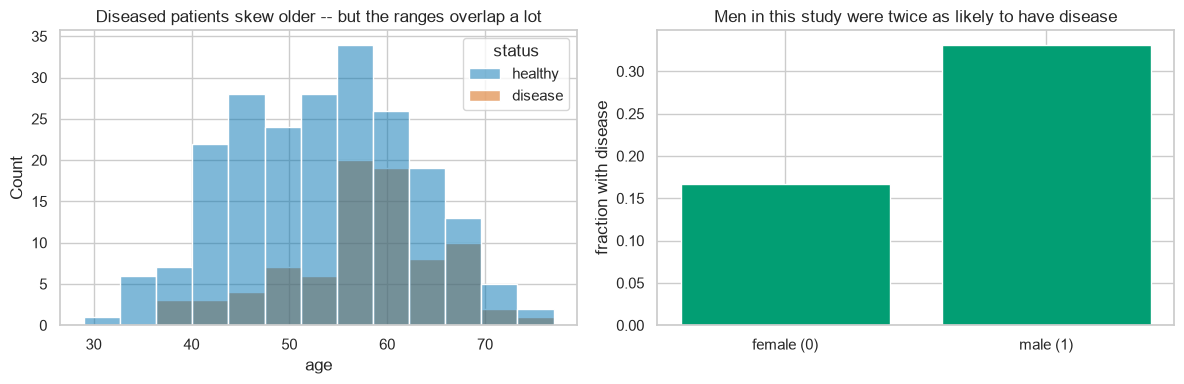

In [8]:
# A readable text label for each patient, for plot legends.
# .map() swaps each value for its replacement: 0 -> "healthy", 1 -> "disease".
df["status"] = df["disease"].map({0: "healthy", 1: "disease"})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: age distributions, one semi-transparent layer per group so the
# shapes can be compared directly (multiple="layer" does the layering).
sns.histplot(data=df, x="age", hue="status", palette=COLORS,
             multiple="layer", ax=axes[0])
axes[0].set_title("Diseased patients skew older -- but the ranges overlap a lot")

# Right: disease rate within each sex (coded 0 = female, 1 = male here).
rate_by_sex = df.groupby("sex")["disease"].mean()
axes[1].bar(["female (0)", "male (1)"], rate_by_sex, color=palette[2])
axes[1].set_ylabel("fraction with disease")
axes[1].set_title("Men in this study were twice as likely to have disease")

plt.tight_layout()
plt.show()

Note the overlap in that age plot: plenty of 60-year-olds are healthy and some 40-year-olds are sick. No single measurement separates the groups — that overlap is the whole reason this module exists.

### The 73% trap

Only ~28% of these patients have disease. So consider the world's laziest "model": it predicts **healthy for every single patient**, without looking at a single measurement.

In [9]:
# The lazy model: an array of zeros, one "healthy" verdict per patient.
# np.zeros(n) builds an array of n zeros.
always_healthy = np.zeros(len(df))

# Accuracy = the fraction of predictions that match the truth.
# (comparing arrays gives True/False per patient; the mean of those is the fraction True)
baseline_accuracy = (always_healthy == df["disease"]).mean()
print("accuracy of a model that never detects anything:", round(baseline_accuracy, 3))

accuracy of a model that never detects anything: 0.721


**72% accurate, and it sends home every sick patient in Ohio.** That number is our floor: any model that can't clearly beat it — *and* catch actual sick people — is medically useless no matter what its accuracy says. Keep 0.72 in mind for the rest of the notebook.

## 3. Logistic regression — an S-curve that outputs probabilities

Module 05's linear regression predicted a number. Here we want a probability: "this patient is 80% likely to have disease" is far more useful to a doctor than a bare yes/no. **Logistic regression** computes a weighted-sum score exactly like linear regression, then squashes that score through the S-shaped **sigmoid** so it lands between 0 and 1 — the same S-shape as a dose–response curve in pharmacology (flat, steep through the middle, flat again).

First, the honest split from Module 04 — a test set the model never sees during training.

In [10]:
from sklearn.model_selection import train_test_split   # the honest-split tool (Module 04)

# X = the measurements (features). We drop the answer column and the text label.
X = df.drop(columns=["disease", "status"])
y = df["disease"]                 # y = the label we want to predict

# stratify=y keeps the healthy/disease ratio identical in both halves --
# important here, because the sick patients are a minority we can't waste.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)

print("training patients:", len(X_train))
print("test patients:    ", len(X_test), "( of which", int(y_test.sum()), "have disease )")

training patients: 223
test patients:     75 ( of which 21 have disease )


To *see* the sigmoid, we first train a mini-model that looks at just **one** feature: `max_heart_rate`, the highest rate the heart reached on the treadmill. Medically, a heart that can't speed up when asked is a worrying sign — so we expect the probability of disease to *fall* as max heart rate rises.

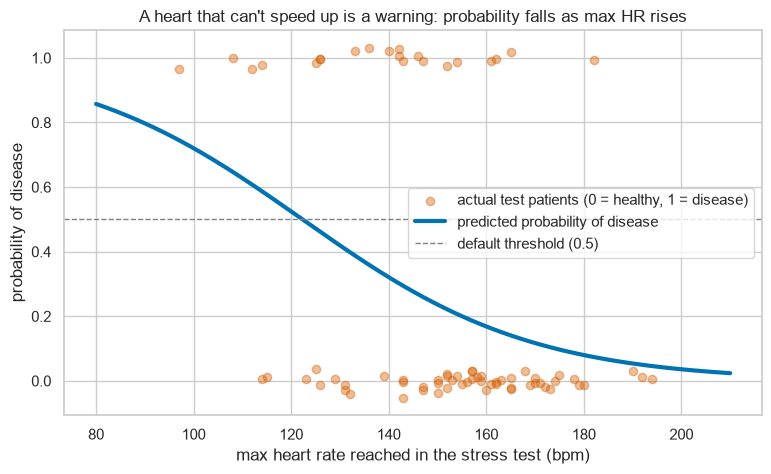

In [11]:
from sklearn.linear_model import LogisticRegression

# A model that sees ONLY max heart rate, so its S-curve fits on one plot.
# Double brackets [["max_heart_rate"]] keep the selection a TABLE (DataFrame),
# the shape scikit-learn expects; single brackets would give a lone column.
hr_model = LogisticRegression()
hr_model.fit(X_train[["max_heart_rate"]], y_train)

# A smooth range of heart rates to draw the curve over.
# np.linspace(80, 210, 200) = 200 evenly spaced values from 80 to 210.
hr_range = pd.DataFrame({"max_heart_rate": np.linspace(80, 210, 200)})

# predict_proba() returns TWO columns per patient: [P(healthy), P(disease)].
# [:, 1] means "all rows, column 1" -- the probability of disease.
curve = hr_model.predict_proba(hr_range)[:, 1]

fig, ax = plt.subplots(figsize=(9, 5))

# The real test patients, drawn at height 0 (healthy) or 1 (diseased),
# with a tiny random up/down "jitter" so overlapping dots stay visible.
jitter = np.random.normal(0, 0.02, size=len(y_test))
ax.scatter(X_test["max_heart_rate"], y_test + jitter, alpha=0.4,
           color=COLORS["disease"], label="actual test patients (0 = healthy, 1 = disease)")

ax.plot(hr_range["max_heart_rate"], curve, color=COLORS["healthy"],
        linewidth=3, label="predicted probability of disease")
ax.axhline(0.5, color="grey", linestyle="--", linewidth=1, label="default threshold (0.5)")

ax.set_xlabel("max heart rate reached in the stress test (bpm)")
ax.set_ylabel("probability of disease")
ax.set_title("A heart that can't speed up is a warning: probability falls as max HR rises")
ax.legend()
plt.show()

There's the sigmoid from the README, fitted to real patients: around 100 bpm the model says ~70% disease risk; by 190 bpm it's down near 5%. One feature is a blunt instrument, though — plenty of red dots sit on the "wrong" side. Now the real model, using **all** the measurements at once:

In [12]:
# The full model: a weighted sum over all 15 feature columns, then the sigmoid.
# max_iter=5000 simply allows the fitting algorithm more steps to settle
# (our columns live on very different scales, so it needs more than the default).
logreg = LogisticRegression(max_iter=5000)
logreg.fit(X_train, y_train)

# For a classifier, .score() returns accuracy.
print("accuracy on training patients:", round(logreg.score(X_train, y_train), 3))
print("accuracy on test patients:    ", round(logreg.score(X_test, y_test), 3))

accuracy on training patients: 0.861
accuracy on test patients:     0.88


**88% on patients it has never seen** — comfortably above the 72% lazy baseline. Module 04 would have declared victory here. This module is about why we can't.

## 4. The confusion matrix — four outcomes, not one number

For a yes/no test there are exactly four possible outcomes (right two ways, wrong two ways). The **confusion matrix** counts them. Rows are *the truth*, columns are *the prediction* — the same layout as the anatomy figure in the README.

[[53  1]
 [ 8 13]]


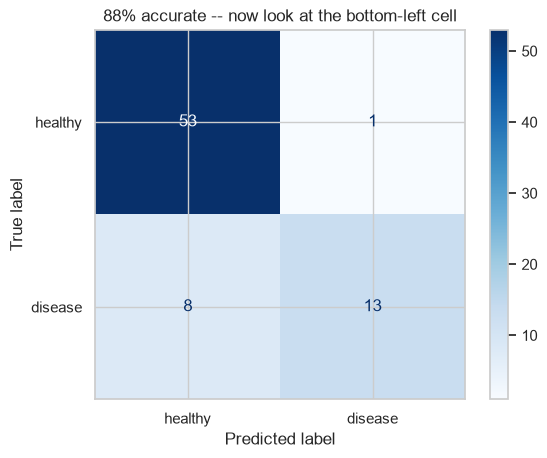

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# The model's yes/no verdicts for the 75 test patients (default threshold, 0.5).
pred = logreg.predict(X_test)

# Count the four outcomes: rows = truth, columns = prediction.
cm = confusion_matrix(y_test, pred)
print(cm)

# from_predictions() draws the same matrix as a shaded grid with counts inside.
ConfusionMatrixDisplay.from_predictions(
    y_test, pred, display_labels=["healthy", "disease"], cmap="Blues")
plt.title("88% accurate -- now look at the bottom-left cell")
plt.show()

Read it like a chart in a patient file:

- **Top-left, 53 — true negatives.** Healthy, correctly cleared. Everyone goes home relieved.
- **Top-right, 1 — false positive.** One healthy patient flagged: a scare and a follow-up angiogram they didn't need. Costly, not catastrophic.
- **Bottom-right, 13 — true positives.** Sick and caught. Treatment can start.
- **Bottom-left, 8 — false negatives.** *Eight patients with real coronary artery disease, told they were fine and sent home.*

The same model, described twice: "88% accurate" and "misses 8 of 21 sick patients". Both true. Only one belongs in a hospital brochure.

## 5. Sensitivity & specificity, by hand

You already know the right vocabulary from lab tests — a PCR assay is quoted by its **sensitivity** (of the truly infected, what fraction does it catch?) and **specificity** (of the truly uninfected, what fraction does it correctly clear?). Same words, same formulas, straight from the matrix cells. Let's compute them by hand once so the names attach to cells, not to memorized formulas.

In [14]:
# Pull the four cells out of the matrix by position.
# cm[row, column]: row 0 = actually healthy, row 1 = actually sick;
#                  column 0 = predicted healthy, column 1 = predicted disease.
true_negatives  = cm[0, 0]
false_positives = cm[0, 1]
false_negatives = cm[1, 0]
true_positives  = cm[1, 1]

# Sensitivity: of the actually-sick patients, what fraction did we catch?
sensitivity = true_positives / (true_positives + false_negatives)

# Specificity: of the actually-healthy patients, what fraction did we clear?
specificity = true_negatives / (true_negatives + false_positives)

print("sensitivity:", round(sensitivity, 2),
      "-- caught", true_positives, "of", true_positives + false_negatives, "sick patients")
print("specificity:", round(specificity, 2),
      "-- cleared", true_negatives, "of", true_negatives + false_positives, "healthy patients")

sensitivity: 0.62 -- caught 13 of 21 sick patients
specificity: 0.98 -- cleared 53 of 54 healthy patients


Sensitivity 0.62: as a diagnostic, this "88% accurate" model catches barely 6 sick patients in 10. A PCR test with that sensitivity would be pulled from the market.

Machine learning grew up outside the clinic and invented its own names. **Recall** is *exactly* sensitivity — same formula, different community. **Precision** is a genuinely different question: *of the patients we flagged, how many were really sick?* — how trustworthy a positive result is.

In [15]:
from sklearn.metrics import recall_score, precision_score

# recall_score computes TP / (TP + FN) -- exactly our sensitivity.
print("recall   :", round(recall_score(y_test, pred), 2),
      "  <- identical to the sensitivity we computed by hand")

# precision_score computes TP / (TP + FP) -- trustworthiness of a positive.
print("precision:", round(precision_score(y_test, pred), 2),
      "  <- when this model says 'disease', it is almost always right")

recall   : 0.62   <- identical to the sensitivity we computed by hand
precision: 0.93   <- when this model says 'disease', it is almost always right


Precision 0.93, sensitivity 0.62: this model is *cautious*. It rarely cries wolf — but pays for that caution by missing wolves. That caution isn't a law of nature; it's a **choice**, hiding in plain sight.

## 6. Moving the threshold

`predict()` has been silently converting probabilities to verdicts using a cutoff of 0.5 — a default, not a medical judgment. The probabilities themselves are richer:

In [16]:
# The probabilities behind the verdicts. [:, 1] = the "disease" column again.
probs = logreg.predict_proba(X_test)[:, 1]

# Peek at the first 8 test patients: predicted probability next to the truth.
peek = pd.DataFrame({"P(disease)": probs.round(2), "truth": y_test})
peek.head(8)

,P(disease),truth
279,0.12,0
21,0.01,0
269,0.11,0
255,0.06,0
116,0.16,0
292,0.22,1
114,0.09,0
288,0.06,0


A patient at probability 0.45 gets called "healthy" by the 0.5 rule — but would *you* send someone home at 45% odds of coronary artery disease? Let's slide the cutoff ourselves and watch all four cells of the matrix respond:

threshold 0.3:  sensitivity 0.76   specificity 0.96   accuracy 0.91
threshold 0.5:  sensitivity 0.62   specificity 0.98   accuracy 0.88
threshold 0.7:  sensitivity 0.33   specificity 0.98   accuracy 0.80


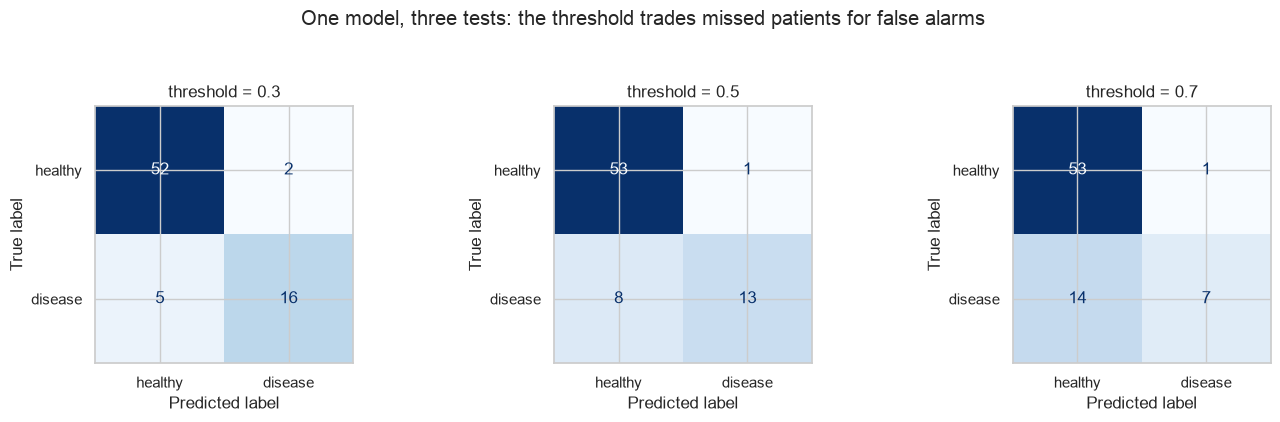

In [17]:
thresholds = [0.3, 0.5, 0.7]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# range(len(...)) gives positions 0, 1, 2 so we can grab both the
# threshold and the matching subplot axis.
for i in range(len(thresholds)):
    t = thresholds[i]

    # Flag a patient when their probability reaches the threshold.
    # astype(int) turns the True/False answers into 1/0 predictions.
    pred_t = (probs >= t).astype(int)

    cm_t = confusion_matrix(y_test, pred_t)
    sens = cm_t[1, 1] / (cm_t[1, 1] + cm_t[1, 0])   # caught / all sick
    spec = cm_t[0, 0] / (cm_t[0, 0] + cm_t[0, 1])   # cleared / all healthy
    acc  = (cm_t[0, 0] + cm_t[1, 1]) / len(y_test)  # correct / everyone

    # In an f-string, :.2f means "show 2 decimal places".
    print(f"threshold {t}:  sensitivity {sens:.2f}   specificity {spec:.2f}   accuracy {acc:.2f}")

    # Draw this threshold's matrix on its own subplot.
    disp = ConfusionMatrixDisplay(cm_t, display_labels=["healthy", "disease"])
    disp.plot(ax=axes[i], cmap="Blues", colorbar=False)
    axes[i].set_title(f"threshold = {t}")

fig.suptitle("One model, three tests: the threshold trades missed patients for false alarms", y=1.05)
plt.tight_layout()
plt.show()

Same model, three different diagnostic tests:

- **0.3 — the screening test.** Sensitivity jumps to 0.76: five of the eight missed patients are now caught, at the price of one extra false alarm. (Notice accuracy went *up* too — 0.5 wasn't even the accuracy-maximizing choice.) This is the PCR-during-an-outbreak mindset: catch everything, sort out the false alarms later.
- **0.5 — the default.** Nobody chose it; it shipped with the software.
- **0.7 — the confirmatory test.** Almost never cries wolf — the mindset for expensive or risky next steps — but now sends *14* sick patients home. Unforgivable as a first-line test.

The threshold is a medical decision dressed up as a software default. In a clinic, choosing it belongs to the cardiologist — your job is to show them the menu of trade-offs. Which brings us to...

## 7. The ROC curve — the whole trade-off in one picture

Instead of trying three thresholds, try **every** threshold: for each one, plot the false-alarm rate (x) against the sensitivity (y). The result is the **ROC curve** — the entire menu of tests this model can be, in one picture. Its one-number summary is the **AUC** (area under the curve): 1.0 = a perfect test exists at some threshold, 0.5 = the model ranks patients no better than a coin flip.

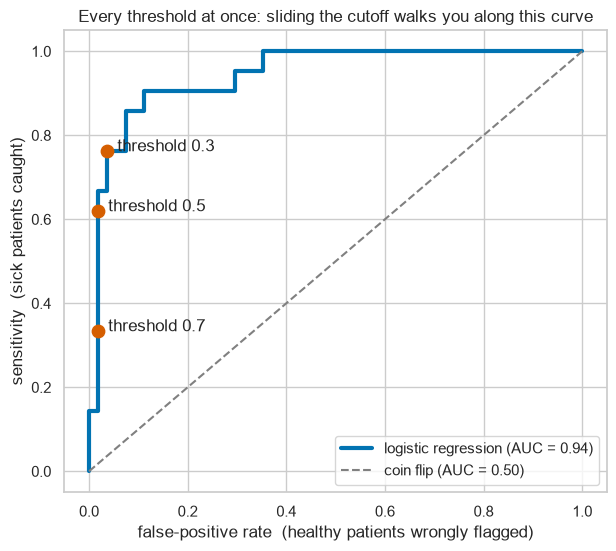

In [18]:
from sklearn.metrics import roc_curve, roc_auc_score

# roc_curve() slides the threshold through every possible value and returns:
#   fpr = false-positive rate = 1 - specificity  (false alarms, x-axis)
#   tpr = true-positive rate  = sensitivity      (catches, y-axis)
fpr, tpr, cutoffs = roc_curve(y_test, probs)
auc = roc_auc_score(y_test, probs)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color=COLORS["healthy"], linewidth=3,
        label=f"logistic regression (AUC = {auc:.2f})")

# The coin-flip diagonal: a model that ranks patients randomly.
ax.plot([0, 1], [0, 1], color="grey", linestyle="--", label="coin flip (AUC = 0.50)")

# Mark where our three familiar thresholds sit on the curve.
for t in thresholds:
    pred_t = (probs >= t).astype(int)
    cm_t = confusion_matrix(y_test, pred_t)
    sens = cm_t[1, 1] / (cm_t[1, 1] + cm_t[1, 0])
    spec = cm_t[0, 0] / (cm_t[0, 0] + cm_t[0, 1])
    ax.scatter(1 - spec, sens, s=80, zorder=3, color=COLORS["disease"])
    ax.annotate(f"  threshold {t}", (1 - spec, sens))

ax.set_xlabel("false-positive rate  (healthy patients wrongly flagged)")
ax.set_ylabel("sensitivity  (sick patients caught)")
ax.set_title("Every threshold at once: sliding the cutoff walks you along this curve")
ax.legend()
plt.show()

Choosing a threshold just picks your point on this curve — up and to the right catches more disease at the cost of more alarms. AUC 0.94 says the *ranking* is genuinely good: the curve hugs the top-left corner, far above the coin-flip diagonal. AUC is also the fairest way to compare two models, because it doesn't depend on any particular threshold choice. Remember that — we're about to have rivals.

## 8. A decision tree you can read

A cardiologist doesn't compute weighted sums; she follows a flowchart — *if this, check that*. A **decision tree** is a model with exactly that shape, and the algorithm designs the flowchart itself: at each step it searches every measurement and every cutoff for the question that best separates sick from healthy, asks it, and repeats on each branch. `max_depth=3` limits it to three questions deep so we can read the whole thing.

train accuracy: 0.88
test accuracy:  0.77


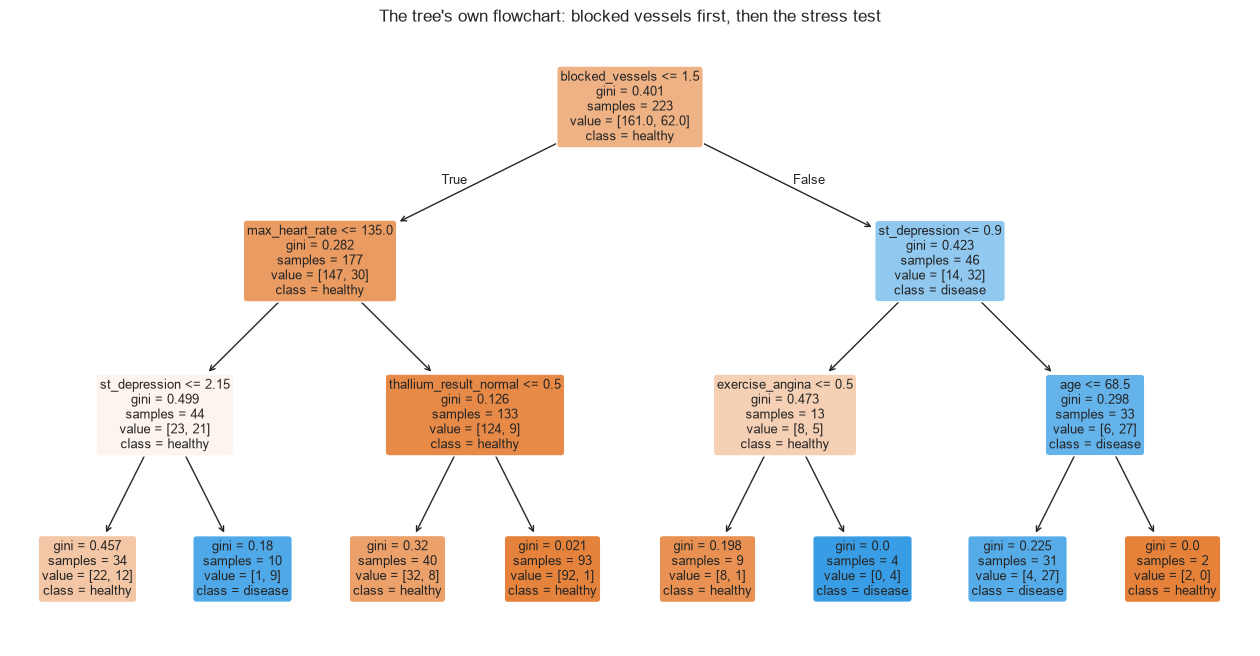

In [19]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# max_depth=3: at most three yes/no questions per patient.
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)

print("train accuracy:", round(tree.score(X_train, y_train), 2))
print("test accuracy: ", round(tree.score(X_test, y_test), 2))

# plot_tree() draws the fitted flowchart.
#   filled=True    shades each box toward its majority class
#   samples        = how many training patients reached that box
#   value          = [healthy, disease] counts among them
fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(tree,
          feature_names=list(X.columns),          # label questions with our column names
          class_names=["healthy", "disease"],     # label the verdicts
          filled=True, rounded=True, fontsize=9, ax=ax)
ax.set_title("The tree's own flowchart: blocked vessels first, then the stress test")
plt.show()

Read it top-down, like the README's flowchart figure (which was a simplified sketch of exactly this tree): the root question is **how many vessels look blocked** — the tree discovered on its own that this is the single most informative split. On the "few blockages" side it next asks about **max heart rate**; on the "blockages" side, about **ST depression**. It reinvented a cardiology workup from raw data.

But notice: train accuracy 0.88, test accuracy 0.77 — a gap. Trees have Module 05's disease in severe form. Watch what happens with no depth limit:

In [20]:
# No max_depth: the tree keeps asking questions until every single
# training patient is classified perfectly -- i.e., memorized.
deep_tree = DecisionTreeClassifier(random_state=42)
deep_tree.fit(X_train, y_train)

print("deep tree, train accuracy:", round(deep_tree.score(X_train, y_train), 2),
      "  <- perfect score = memorization, not learning")
print("deep tree, test accuracy: ", round(deep_tree.score(X_test, y_test), 2),
      "  <- and new patients don't benefit at all")

deep tree, train accuracy: 1.0   <- perfect score = memorization, not learning
deep tree, test accuracy:  0.8   <- and new patients don't benefit at all


100% on training patients, ~80% on new ones — the overfitting triptych from Module 05, now in flowchart form. A tree left alone will happily grow a special branch for every quirky patient it has ever met.

## 9. Random forest — many trees voting

The cure for one overconfident doctor is a **panel** of them. A random forest grows hundreds of trees, each trained on a slightly different random re-sample of the patients, and each allowed to consider only a random subset of the measurements at each question. Every tree overfits in its *own* direction — and when they vote, the individual quirks cancel out while the real signal adds up.

In [21]:
from sklearn.ensemble import RandomForestClassifier
# (an "ensemble" = a model made of many models)

# 300 trees. Each patient's final probability = fraction of trees voting "disease".
forest = RandomForestClassifier(n_estimators=300, random_state=42)
forest.fit(X_train, y_train)

forest_probs = forest.predict_proba(X_test)[:, 1]   # the disease column, as before

print("test accuracy:", round(forest.score(X_test, y_test), 2),
      "  (single depth-3 tree scored 0.77)")
print("AUC:          ", round(roc_auc_score(y_test, forest_probs), 2),
      "  (single tree: 0.78, logistic regression: 0.94)")

test accuracy: 0.84   (single depth-3 tree scored 0.77)
AUC:           0.95   (single tree: 0.78, logistic regression: 0.94)


The vote beats the single tree decisively. We lose the readable flowchart — you can't read 300 flowcharts — but the forest offers a consolation prize: **feature importance**, a score for how much each measurement contributed to its decisions, summed across every question in every tree.

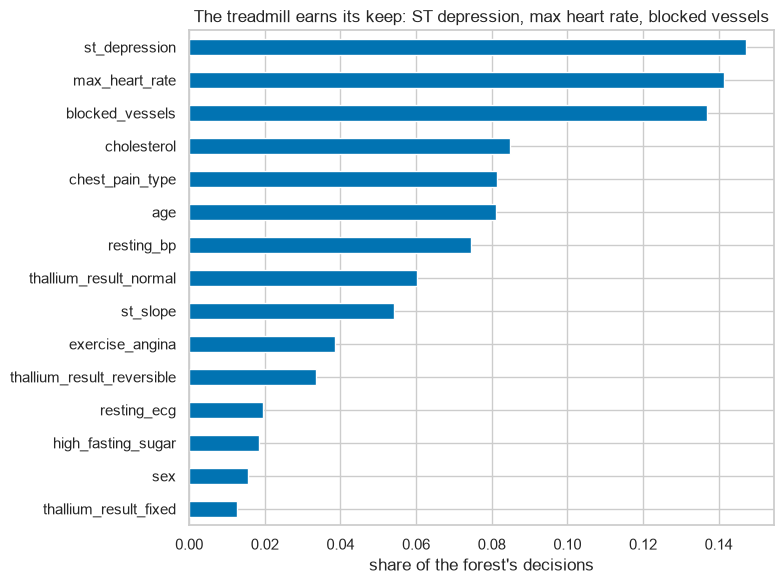

In [22]:
# feature_importances_ has one score per feature column; they sum to 1.
# Wrapping it in a Series attaches the column names to the scores (Module 02).
importance = pd.Series(forest.feature_importances_, index=X.columns)

# Sort smallest-first so the biggest bars land on TOP of a horizontal chart.
importance = importance.sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
importance.plot.barh(ax=ax, color=COLORS["healthy"])   # barh = horizontal bars
ax.set_xlabel("share of the forest's decisions")
ax.set_title("The treadmill earns its keep: ST depression, max heart rate, blocked vessels")
plt.tight_layout()
plt.show()

A biologist's reading: the three most diagnostic measurements — ST depression, max heart rate, and blocked vessels — all come from *stressing* the heart and watching what happens, not from resting numbers. Cholesterol and resting blood pressure, the measurements everyone knows, rank mid-table; whether fasting blood sugar was high barely registered. (One caution: importance means "the forest used it", not "it causes disease" — correlated measurements can share or steal each other's credit.)

## 10. Which model would you deploy?

Time to line up every model we built — plus the lazy baseline — on the same report card.

In [23]:
# A small helper function so we don't repeat the same six lines per model.
# ("def" defines a reusable function; everything indented under it runs
#  each time the function is called.)
def report(name, predictions, probabilities):
    cm_r = confusion_matrix(y_test, predictions)
    sens = cm_r[1, 1] / (cm_r[1, 1] + cm_r[1, 0])
    spec = cm_r[0, 0] / (cm_r[0, 0] + cm_r[0, 1])
    acc = (cm_r[0, 0] + cm_r[1, 1]) / len(y_test)
    auc_r = roc_auc_score(y_test, probabilities)
    # Return one row of the report card as a dictionary.
    return {"model": name,
            "accuracy": round(acc, 2),
            "sensitivity": round(sens, 2),
            "specificity": round(spec, 2),
            "AUC": round(auc_r, 2)}

rows = []
zeros = np.zeros(len(y_test))    # the lazy model: all-healthy verdicts, all-zero probabilities
rows.append(report("always say healthy", zeros, zeros))
rows.append(report("logistic regression @ 0.5", (probs >= 0.5).astype(int), probs))
rows.append(report("logistic regression @ 0.3 (screening)", (probs >= 0.3).astype(int), probs))
rows.append(report("decision tree (depth 3)", tree.predict(X_test), tree.predict_proba(X_test)[:, 1]))
rows.append(report("random forest", forest.predict(X_test), forest_probs))

report_card = pd.DataFrame(rows)
report_card

,model,accuracy,sensitivity,specificity,AUC
0,always say healthy,0.72,0.00,1.00,0.50
1,logistic regression @ 0.5,0.88,0.62,0.98,0.94
2,logistic regression @ 0.3 (screening),0.91,0.76,0.96,0.94
3,decision tree (depth 3),0.77,0.33,0.94,0.78
4,random forest,0.84,0.48,0.98,0.95


Read the report card like a hospital purchasing committee:

- **Accuracy alone would tell you almost nothing.** The lazy model posts 0.72 while missing *every* case, and the two logistic rows differ more in what they miss than in their accuracy.
- **The forest ranks patients best** (AUC 0.95) — yet at the default threshold its sensitivity is under 0.5. A great engine shipped with terrible factory settings.
- **Logistic regression at 0.3** is the best *test* on this table: sensitivity 0.76, specificity 0.96 — and, unlike the forest, a cardiologist can inspect its weights and see *why* it flagged a patient. In medicine, explainability is not a luxury.

The deployment answer, then, isn't just a model — it's a **model plus a threshold, chosen for the clinical job**: screening the general population (push sensitivity up, accept alarms) versus confirming before surgery (the reverse). And honestly? With only 298 patients, the next module's question is already knocking: how much should we trust numbers measured on a single 75-patient test set? Module 07 — the honest-scientist workflow — is about exactly that.

Now do [exercises.md](exercises.md) — the challenge at the end asks you to draw the sensitivity/specificity trade-off across *all* thresholds and pick one for a real clinic.